### Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict, Counter
import accelerate
import transformers

from datasets import Dataset, load_dataset
from transformers import (
    DistilBertTokenizerFast, 
    DistilBertForSequenceClassification, 
    TrainingArguments, 
    Trainer
)

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_recall_fscore_support,
    accuracy_score
)

from flask import Flask, request, jsonify
from wordcloud import WordCloud

# torch==2.8.0 torchvision==0.23.0 torchaudio==2.8.0
import torch
import os
import json

### Configuration

In [2]:
#DATA_PATH = "F:/RAID_dataset"

#TRAIN_FILE = os.path.join(DATA_PATH, "train.csv")
#TEST_FILE = os.path.join(DATA_PATH, "test.csv")

CHUNK_SIZE = 50000
TARGET_PER_CLASS = 2000

dataset_stream  = load_dataset(
    "tarryzhang/AIGTBench", 
    split="train", 
    streaming=True
)

### View Sample

In [ ]:
print("Sample Data:\n")

for i, example in enumerate(dataset_stream):
    print(example)
    if i == 4:
        break


Sample Data:

{'text': 'It’s founder and CEO, Jeff Bezos, shall step down in July and pave the way for Andy Jassy, a company executive with the company since 1997. Jassy is a long-time veteran of the company, and Jeff Bezos paid him a rich compliment when he announced the change: “Andy is well known inside the company and has been at Amazon almost as long as I have. He will be an outstanding leader, and he has my full confidence.” For the last 15 years, he has run Amazon Web Services (AWS), a mundane but very essential and highly profitable cloud computing business that controls about a third of the industry. We usually associate the Amazon brand with online shopping, but after two decades of growth, the company has multiple verticals, and this requires someone who’s been at the center of it all since the beginning. Jassy has been a key player, but one who has worked largely in the background. While there’s no doubt he’ll be able to manage Amazon’s cutting-edge technology, the challeng

In [3]:
label_counts = Counter()
text_lengths = []
word_counts = []
sample_texts = []

class_data = defaultdict(list)

for i, example in enumerate(dataset_stream):
    try:
        text = example["text"]
        label = example["label"]
    except:
        continue

    if text is None:
        continue

    model_label = "human" if label == 0 else "ai"

    label_counts.update([model_label])
    text_lengths.append(len(text))
    word_counts.append(len(text.split()))

    if len(sample_texts) < 10:
        sample_texts.append(text)

    class_data[model_label].append({
        "text": text,
        "model": model_label
    })

print("\nLabel Distribution:")
print(label_counts)

print("\nText Length Stats:")
print(f"Mean: {np.mean(text_lengths):.2f}, Max: {np.max(text_lengths)}, Min: {np.min(text_lengths)}")

print("\nSample Text:")
for i, t in enumerate(sample_texts[:3]):
    print(f"\nSample {i+1}:\n{t[:300]}...\n")


Label Distribution:
Counter({'ai': 283199, 'human': 241229})

Text Length Stats:
Mean: 1181.51, Max: 23465, Min: 2

Sample Text:

Sample 1:
It’s founder and CEO, Jeff Bezos, shall step down in July and pave the way for Andy Jassy, a company executive with the company since 1997. Jassy is a long-time veteran of the company, and Jeff Bezos paid him a rich compliment when he announced the change: “Andy is well known inside the company and ...


Sample 2:
# The Future of Non-Fungible Tokens: A Deep Dive into Phantasma and GOATi Entertainment

The future of Non-Fungible Tokens (NFTs) is unfolding before us, thanks to the advanced blockchain technology provided by Phantasma. As Arthur C. Clarke famously said, “Any sufficiently advanced technology is in...


Sample 3:
These technologies are getting more and more advanced every year. The types of data and ways to interpret them are also diversifying. Currently, these technologies are helpful in a wide range of areas, such as recommendation se

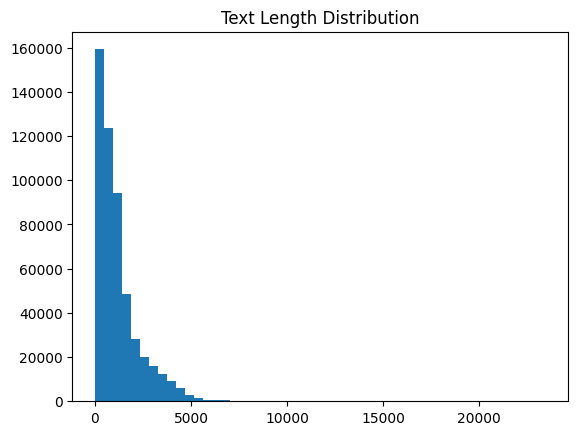

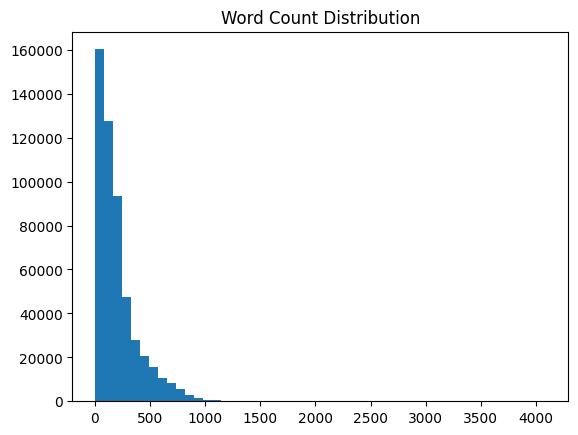

In [5]:
plt.figure()
plt.hist(text_lengths, bins=50)
plt.title("Text Length Distribution")
plt.show()

plt.figure()
plt.hist(word_counts, bins=50)
plt.title("Word Count Distribution")
plt.show()

In [6]:
vocab_counter = Counter()

dataset_stream = load_dataset(
    "tarryzhang/AIGTBench",
    split="train",
    streaming=True
)

for i, example in enumerate(dataset_stream):
    try:
        text = example["text"]
    except:
        continue

    if text is None:
        continue

    vocab_counter.update(text.split())

    if i > 200000:
        break

print("Top 20 words:")
print(vocab_counter.most_common(20))

Top 20 words:
[('the', 2303838), ('to', 1732523), ('and', 1629935), 
('a', 1454221), ('of', 1303117), ('in', 753151), 
('is', 669986), ('that', 643885), ('I', 557193), 
('for', 492854), ('you', 474226), ('with', 390356), 
('on', 357579), ('it', 334405), ('are', 324987), 
('The', 309931), ('your', 309218), ('can', 306628), 
('be', 302848), ('as', 292899)]


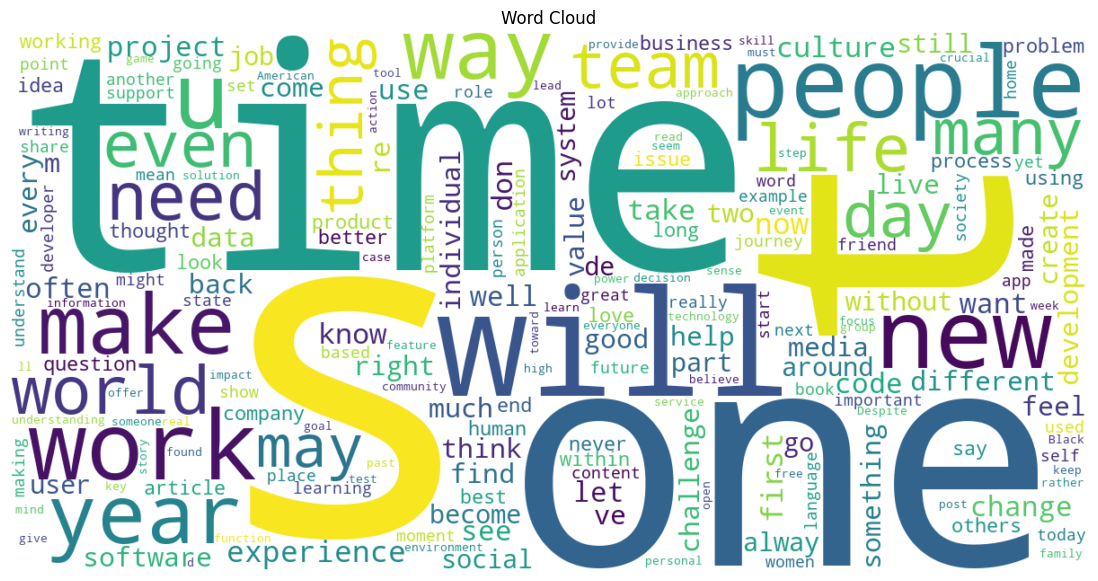

In [7]:
text_corpus = ""

dataset_stream = load_dataset(
    "tarryzhang/AIGTBench",
    split="train",
    streaming=True
)

for i, example in enumerate(dataset_stream):
    try:
        text = example["text"]
    except:
        continue

    if text is None:
        continue

    text_corpus += text + " "

    if i > 50000:
        break

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    max_words=200,
    collocations=False
).generate(text_corpus)

plt.figure(figsize=(15,7))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud")
plt.show()

In [4]:
df = pd.DataFrame([item for sublist in class_data.values() for item in sublist])
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print(df["model"].value_counts())

df["text"] = df["text"].str.lower()

label2id = {"human": 0, "ai": 1}
id2label = {0: "human", 1: "ai"}

df["label"] = df["model"].map(label2id)
df = df[["text", "label"]]

dataset = Dataset.from_pandas(df)
dataset = dataset.train_test_split(test_size=0.2)

model
ai       283199
human    241229
Name: count, dtype: int64


In [5]:
tokenizer = DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")

def tokenize(example):
    return tokenizer(
        example["text"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

dataset = dataset.map(tokenize, batched=True)
dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])

Map:   0%|          | 0/419542 [00:00<?, ? examples/s]

Map:   0%|          | 0/104886 [00:00<?, ? examples/s]

In [6]:
model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=2,
    id2label=id2label,
    label2id=label2id
)

def compute_metrics(pred):
    logits, labels = pred
    preds = np.argmax(logits, axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average='binary'
    )
    acc = accuracy_score(labels, preds)

    return {"accuracy": acc, "f1": f1, "precision": precision, "recall": recall}

training_args = TrainingArguments(
    output_dir="./results",
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    num_train_epochs=1,
    eval_strategy="epoch",
    save_strategy="epoch"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset["train"],
    eval_dataset=dataset["test"],
    processing_class=tokenizer,
    compute_metrics=compute_metrics
)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [11]:


trainer.train()

c:\Users\Shen\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch,Training Loss,Validation Loss


KeyboardInterrupt: 

In [9]:

checkpoint_path = "./results/checkpoint-104886"
model = DistilBertForSequenceClassification.from_pretrained(checkpoint_path)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset["train"],
    eval_dataset=dataset["test"],
    processing_class=tokenizer,
    compute_metrics=compute_metrics
)

trainer.train(resume_from_checkpoint=checkpoint_path)

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


Epoch,Training Loss,Validation Loss


TrainOutput(global_step=104886, training_loss=0.0, metrics={'train_runtime': 0.0, 'total_flos': 1.3893909341733888e+16, 'train_loss': 0.0, 'epoch': 1.0})


Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.80      0.86     48272
           1       0.85      0.96      0.90     56614

    accuracy                           0.89    104886
   macro avg       0.90      0.88      0.88    104886
weighted avg       0.89      0.89      0.88    104886



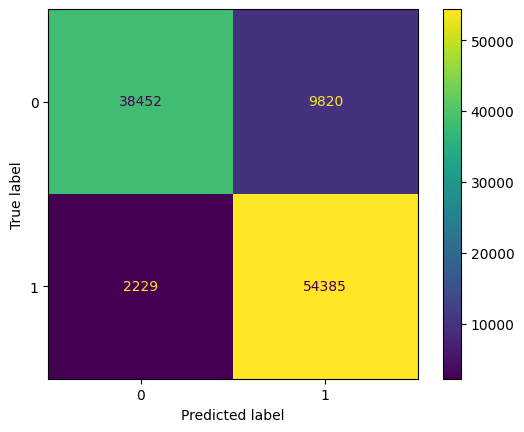

In [12]:
preds = trainer.predict(dataset["test"])

y_true = preds.label_ids
y_pred = np.argmax(preds.predictions, axis=1)

print("\nClassification Report:")
print(classification_report(y_true, y_pred))

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

In [10]:
SAVE_PATH = "./ai_detector_model"

model.save_pretrained(SAVE_PATH)
tokenizer.save_pretrained(SAVE_PATH)

with open(os.path.join(SAVE_PATH, "label_map.json"), "w") as f:
    json.dump(id2label, f)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [11]:
def predict_text(text):
    inputs = tokenizer(
        text.lower(),
        return_tensors="pt",
        truncation=True,
        padding=True
    )

    with torch.no_grad():
        outputs = model(**inputs)

    probs = torch.nn.functional.softmax(outputs.logits, dim=1)

    human_prob = probs[0][0].item()
    ai_prob = probs[0][1].item()

    if human_prob > 0.6:
        final = "Human"
    elif ai_prob > 0.6:
        final = "AI"
    else:
        final = "Uncertain"

    return {
        "final_label": final,
        "human_prob": human_prob,
        "ai_prob": ai_prob
    }

In [ ]:
app = Flask(__name__)

@app.route("/")
def home():
    return """
    <html>
    <body>
        <h2>AI Text Detector</h2>
        <textarea id="text" rows="10" cols="60"></textarea><br><br>
        <button onclick="predict()">Analyze</button>
        <h3 id="result"></h3>

        <script>
        async function predict() {
            const text = document.getElementById("text").value;

            const res = await fetch("/predict", {
                method: "POST",
                headers: {"Content-Type": "application/json"},
                body: JSON.stringify({text})
            });

            const data = await res.json();

            document.getElementById("result").innerText =
                "Final: " + data.final_label +
                " | Human: " + data.human_prob.toFixed(3) +
                " | AI: " + data.ai_prob.toFixed(3);
        }
        </script>
    </body>
    </html>
    """

@app.route("/predict", methods=["POST"])
def api_predict():
    data = request.json
    return jsonify(predict_text(data["text"]))

app.run(host="0.0.0.0", port=5000)

 * Serving Flask app '__main__'
 * Debug mode: off


 * Running on all addresses (0.0.0.0)
 * Running on http://127.0.0.1:5000
 * Running on http://192.168.1.8:5000
Press CTRL+C to quit
127.0.0.1 - - [05/May/2026 17:09:44] "GET / HTTP/1.1" 200 -
127.0.0.1 - - [05/May/2026 17:09:45] "GET /favicon.ico HTTP/1.1" 404 -
[2026-05-05 17:09:47,947] ERROR in app: Exception on /predict [POST]
Traceback (most recent call last):
  File "c:\Users\Shen\AppData\Local\Programs\Python\Python312\Lib\site-packages\flask\app.py", line 1511, in wsgi_app
    response = self.full_dispatch_request()
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Shen\AppData\Local\Programs\Python\Python312\Lib\site-packages\flask\app.py", line 919, in full_dispatch_request
    rv = self.handle_user_exception(e)
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Shen\AppData\Local\Programs\Python\Python312\Lib\site-packages\flask\app.py", line 917, in full_dispatch_request
    rv = self.dispatch_request()
         ^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Shen\